In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk

from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet



from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Text Cleaning & Preprocessing

In [5]:
EMOJI_SENTIMENT = {
    "😀": "happy", "😃": "happy", "😄": "happy", "😁": "happy",
    "😆": "happy", "🤣": "happy", "😂": "happy", "🙂": "happy",
    "😊": "happy", "😍": "love", "🥰": "love", "😘": "love",
    "❤️": "love", "💕": "love", "👍": "good", "👏": "good",
    "🔥": "great", "💯": "perfect", "🎉": "celebration",
    "😢": "sad", "😭": "sad", "😞": "sad", "😔": "sad",
    "😠": "angry", "😡": "angry", "🤮": "disgusting",
    "👎": "bad", "💔": "heartbreak", "😒": "annoyed",
    "🙄": "annoyed", "😤": "frustrated",
}

NEGATION_WORDS = {
    "not", "no", "never", "neither", "nor", "cannot",
    "can't", "won't", "don't", "doesn't", "didn't",
    "isn't", "aren't", "wasn't", "weren't",
    "wouldn't", "shouldn't", "couldn't",
    "hasn't", "haven't", "hadn't", "mustn't"
}


STOP_WORDS = set(stopwords.words("english")) - NEGATION_WORDS

lemmatizer = WordNetLemmatizer()


def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('N'): return wordnet.NOUN
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN


def clean_text(text: str):
    
    text = re.sub(r"<[^>]+>", " ", text)  # 1. Remove HTML

    
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # 2. Remove URLs

    
    for emoji, token in EMOJI_SENTIMENT.items():
        text = text.replace(emoji, f" {token} ")      # 3. Convert emojis → tokens


    text = text.lower()   # 4. Lowercase

    
    text = re.sub(r"n't", " not", text) 
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ll", " will", text)      # 5. Expand common negation contractions
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r"'s", "", text)

    
    text = re.sub(r"\b(not|no|never)\s+(\w+)", r"\1_\2", text)  # 6. Handle negation (attach next word)

    
    text = re.sub(r"[^a-z_\s]", " ", text)   # 7. Remove non-alpha (keep _ for negation tokens)

    
    text = re.sub(r"\s+", " ", text).strip()  # 8. Normalize spaces

    
    tokens = text.split()  # 9. Tokenize

    
    pos_tags = pos_tag(tokens)   # 10. POS tagging + Lemmatization + Stopword removal

    processed_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in pos_tags
        if word not in STOP_WORDS and len(word) > 1
    ]

    return " ".join(processed_tokens)

df["clean_review"] = df["review"].apply(clean_text)

In [6]:
# Test
sample = "This movie is <b>NOT</b> good 😡! Visited http://bad.com for more."
print("Before:", sample)
print("After :", clean_text(sample))

Before: This movie is <b>NOT</b> good 😡! Visited http://bad.com for more.
After : movie not_good angry visit


In [7]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mention watch oz episode hook rig...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


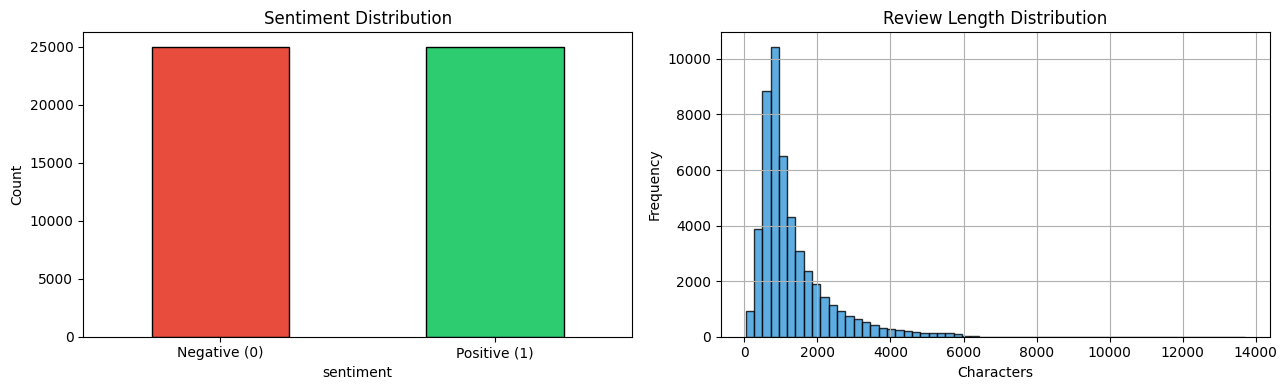

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sentiment distribution
df["sentiment"].value_counts().plot.bar(ax=axes[0], color=["#e74c3c","#2ecc71"], edgecolor="k")
axes[0].set_title("Sentiment Distribution")
axes[0].set_xticklabels(["Negative (0)", "Positive (1)"], rotation=0)
axes[0].set_ylabel("Count")

# Review length distribution
df["review_len"] = df["review"].str.len()
df["review_len"].hist(bins=60, ax=axes[1], color="#3498db", edgecolor="k", alpha=0.8)
axes[1].set_title("Review Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [10]:
df = df.drop_duplicates(subset='clean_review')

df = df[df['clean_review'].str.split().str.len() >= 20]

In [12]:
df.shape

(49256, 4)

In [14]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [15]:
df.head()

,review,sentiment,clean_review,review_len,label
0,One of the other reviewers has mentioned that ...,positive,one reviewer mention watch oz episode hook rig...,1761,1
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...,998,1
2,I thought this was a wonderful way to spend ti...,positive,think wonderful way spend time hot summer week...,926,1
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...,748,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...,1317,1


## Feature Engineering – TF-IDF & CountVectorizer

In [16]:
x = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
# TF-IDF (primary)
tfidf = TfidfVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=3, max_df=0.95)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# CountVectorizer (for comparison / Naïve Bayes)
count_vec = CountVectorizer(max_features=30_000, ngram_range=(1, 2), min_df=3, max_df=0.95)
X_train_cv = count_vec.fit_transform(X_train)
X_test_cv  = count_vec.transform(X_test)

print(f"TF-IDF  feature matrix : {X_train_tfidf.shape}")
print(f"CountVec feature matrix: {X_train_cv.shape}")

TF-IDF  feature matrix : (39404, 30000)
CountVec feature matrix: (39404, 30000)


## Model Training & Comparison
### Baseline Models
- Logistic Regression
- Multinomial Naïve Bayes
- Support Vector Machine (LinearSVC)

### Advanced Models
- Random Forest
- Gradient Boosting